# Session 7: Classification — Disease Prediction from Symptoms

## Why This Session Matters

In the **AI Health Analytics Platform**, we want to move from simply exploring health data to making predictions.

In this session, we will build a model that uses symptoms to predict the most likely disease.

```text
Patient Symptoms  →  ML Classifier  →  Predicted Disease
```

Example:

```text
fever = 1
headache = 1
vomiting = 0
cough = 0

↓

Model

↓

Predicted Disease
```

This is the core idea behind a disease classification system.


## Session Goals

By the end of this session, you should be able to:

1. Explain what classification means
2. Understand binary vs multi-class classification
3. Load and inspect a symptom-based disease dataset
4. Identify features and labels
5. Train a Logistic Regression classifier
6. Evaluate the model using precision, recall, F1-score, and confusion matrix
7. Understand model confidence using probabilities
8. Analyze incorrect or low-confidence predictions
9. Explain why error analysis matters in healthcare


# 1. What is Classification?

Classification means predicting a **category**.

Examples:

| Input | Prediction |
|---|---|
| Email text | Spam / Not Spam |
| Medical image | Cancer / No Cancer |
| Symptoms | Disease name |
| Transaction | Fraud / Normal |

In our case:

```text
Symptoms → Disease
```

The column we want to predict is called the **label** or **target**.


# 2. Binary vs Multi-Class Classification

## Binary Classification

Binary classification means there are only two possible outputs.

```text
Patient Symptoms
      │
      ▼
  Classifier
      │
 ┌────┴────┐
 │         │
Disease   No Disease
```

## Multi-Class Classification

Multi-class classification means there are more than two possible outputs.

```text
Patient Symptoms
      │
      ▼
  Classifier
      │
 ┌────┼────┬────┬────┐
 │    │    │    │
Flu Dengue TB Allergy ...
```

This symptoms dataset is a **multi-class classification** problem because the model predicts one disease from many possible diseases.


# 3. Machine Learning Pipeline

A real ML project usually follows this flow:

```text
Raw Dataset
      │
      ▼
Data Exploration
      │
      ▼
Feature / Label Split
      │
      ▼
Train Model
      │
      ▼
Make Predictions
      │
      ▼
Evaluate Model
      │
      ▼
Analyze Mistakes
      │
      ▼
Improve Model
```

This session focuses on the full cycle from dataset loading to error analysis.


# 4. Import Libraries

We import the tools we need for data analysis, visualization, and machine learning.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


## Why are we doing this?

- `pandas` helps us load and manipulate CSV datasets.
- `numpy` helps with numerical operations.
- `matplotlib` and `seaborn` help us create plots.
- `LogisticRegression` is the classifier we will train.
- `classification_report` and `confusion_matrix` help us evaluate the model.

## Interpretation

Before building any model, we set up our tools. These libraries are standard in beginner machine learning projects.


# 5. Load the Dataset

This notebook expects the same dataset structure as the Kaggle symptoms notebook:

- `Training.csv`
- `Testing.csv`

The training file is used to teach the model.

The testing file is used to evaluate how well the model performs on unseen examples.


In [2]:
train_df = pd.read_csv("Training.csv")
test_df = pd.read_csv("Testing.csv")

train_df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


## Why are we doing this?

We need to load the raw data before we can inspect it or train a model.

## Interpretation

Each row represents one patient/sample.

Most columns are symptoms encoded as:

```text
1 = symptom is present
0 = symptom is not present
```

The target column is:

```text
prognosis
```

This column contains the disease name.


# 6. Inspect the Dataset

Before training a model, always understand the data first.


In [ ]:
train_df.shape

(4920, 134)

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 134 entries, itching to Unnamed: 133
dtypes: float64(1), int64(132), object(1)
memory usage: 5.0+ MB


In [ ]:
train_df.describe()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,Unnamed: 133
count,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,...,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,0.0
mean,0.137805,0.159756,0.021951,0.045122,0.021951,0.162195,0.139024,0.045122,0.045122,0.021951,...,0.021951,0.021951,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171,NaN
std,0.344730,0.366417,0.146539,0.207593,0.146539,0.368667,0.346007,0.207593,0.207593,0.146539,...,0.146539,0.146539,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN


## Why are we doing this?

We want to answer:

- How many rows are in the dataset?
- How many columns are there?
- Are the columns numeric or text?
- Are there missing values?
- Does the dataset look machine-learning-ready?

## Interpretation

This dataset is mostly made of symptom columns with values `0` or `1`.

That means the data is already in a format that a machine learning model can use.

The `prognosis` column is the disease label.


## Practice

Try inspecting the testing dataset yourself.


In [ ]:
# Practice:
# 1. Show the first 5 rows of test_df
# 2. Check the shape of test_df
# 3. Check test_df.info()


# 7. Check the Target Column

The target column is the answer we want the model to predict.


In [ ]:
train_df["prognosis"].unique()

array(['Fungal infection', 'Allergy', 'GERD', 'Chronic cholestasis',
       'Drug Reaction', 'Peptic ulcer diseae', 'AIDS', 'Diabetes ',
       'Gastroenteritis', 'Bronchial Asthma', 'Hypertension ', 'Migraine',
       'Cervical spondylosis', 'Paralysis (brain hemorrhage)', 'Jaundice',
       'Malaria', 'Chicken pox', 'Dengue', 'Typhoid', 'hepatitis A',
       'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E',
       'Alcoholic hepatitis', 'Tuberculosis', 'Common Cold', 'Pneumonia',
       'Dimorphic hemmorhoids(piles)', 'Heart attack', 'Varicose veins',
       'Hypothyroidism', 'Hyperthyroidism', 'Hypoglycemia',
       'Osteoarthristis', 'Arthritis',
       '(vertigo) Paroymsal  Positional Vertigo', 'Acne',
       'Urinary tract infection', 'Psoriasis', 'Impetigo'], dtype=object)

In [ ]:
train_df["prognosis"].nunique()

41

## Why are we doing this?

We need to know how many disease categories the model must predict.

## Interpretation

If there are many unique diseases, this confirms that the task is **multi-class classification**.

The model will not simply predict disease vs no disease.

It will choose one disease label from many possibilities.


# 8. Class Distribution

Now we check how many examples we have for each disease.


In [ ]:
train_df["prognosis"].value_counts()

,count
prognosis,
Fungal infection,120
Allergy,120
GERD,120
Chronic cholestasis,120
Drug Reaction,120
Peptic ulcer diseae,120
AIDS,120
Diabetes,120
Gastroenteritis,120


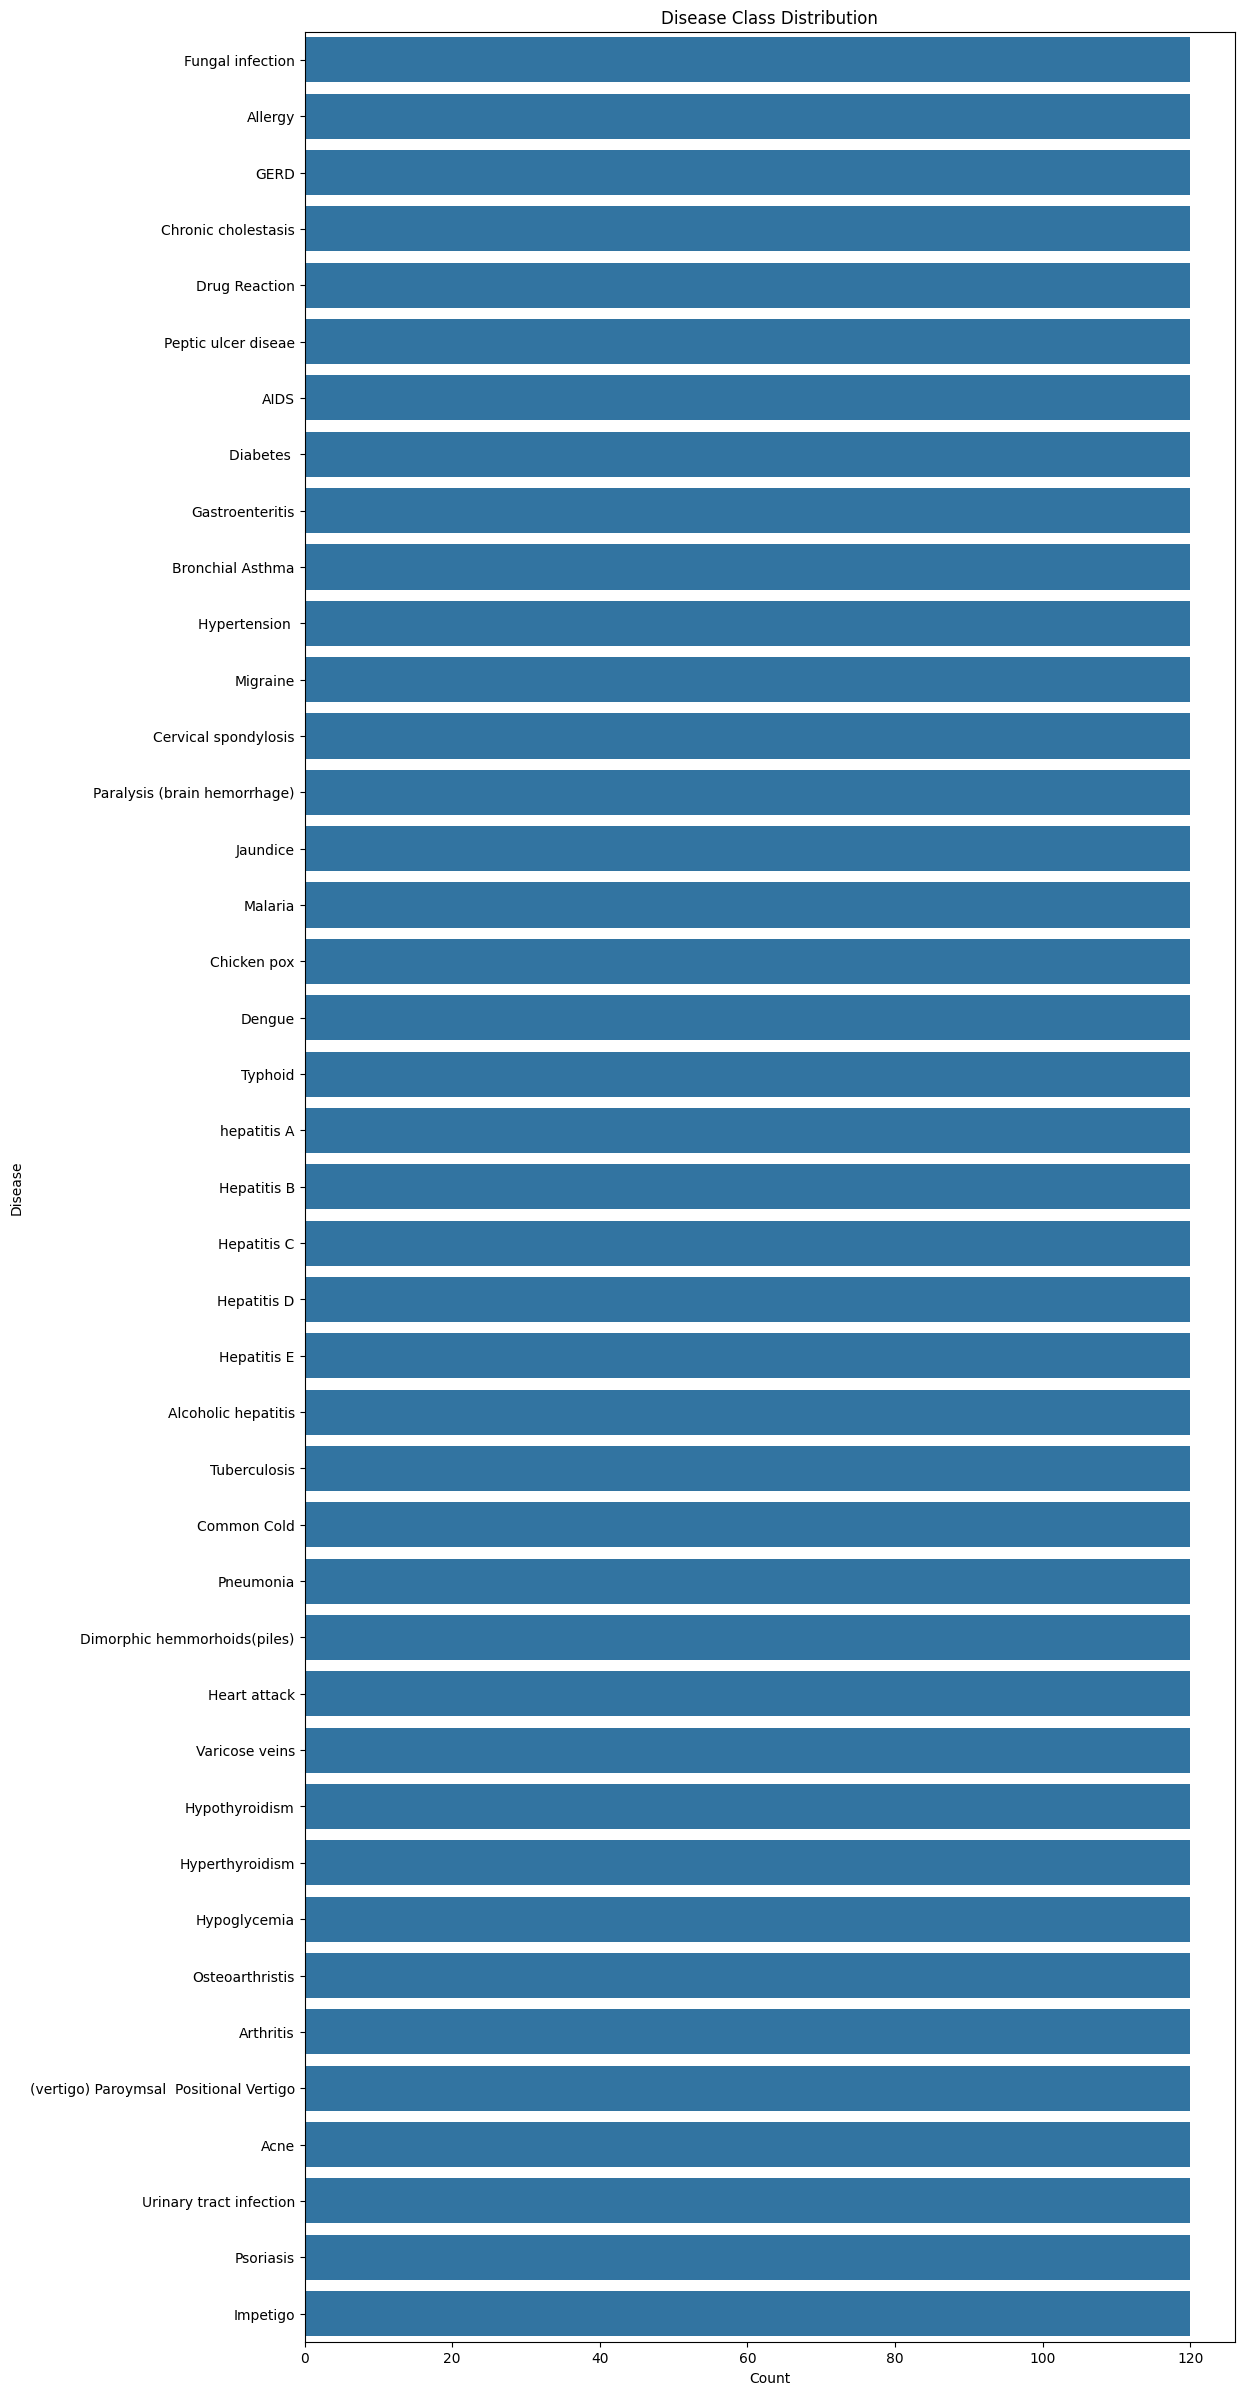

In [ ]:
plt.figure(figsize=(12, 30))
sns.countplot(y="prognosis", data=train_df)
plt.title("Disease Class Distribution")
plt.xlabel("Count")
plt.ylabel("Disease")
plt.show()

## Why are we doing this?

Class distribution helps us check whether the dataset is balanced.

If one disease has many more examples than others, the model may become biased toward that disease.

## Interpretation

A balanced dataset is easier for the model to learn from.

If the bars are similar in size, each disease has a similar number of training examples.

If some bars are much larger, we would need to be careful about class imbalance.


## Practice

Write 1-2 sentences interpreting the class distribution.


In [ ]:
# Practice:
# Is this dataset balanced or imbalanced?
# Explain your answer in 1-2 sentences.


# 9. Visualize Symptom Frequencies

Let's inspect how often some symptoms appear in the dataset.


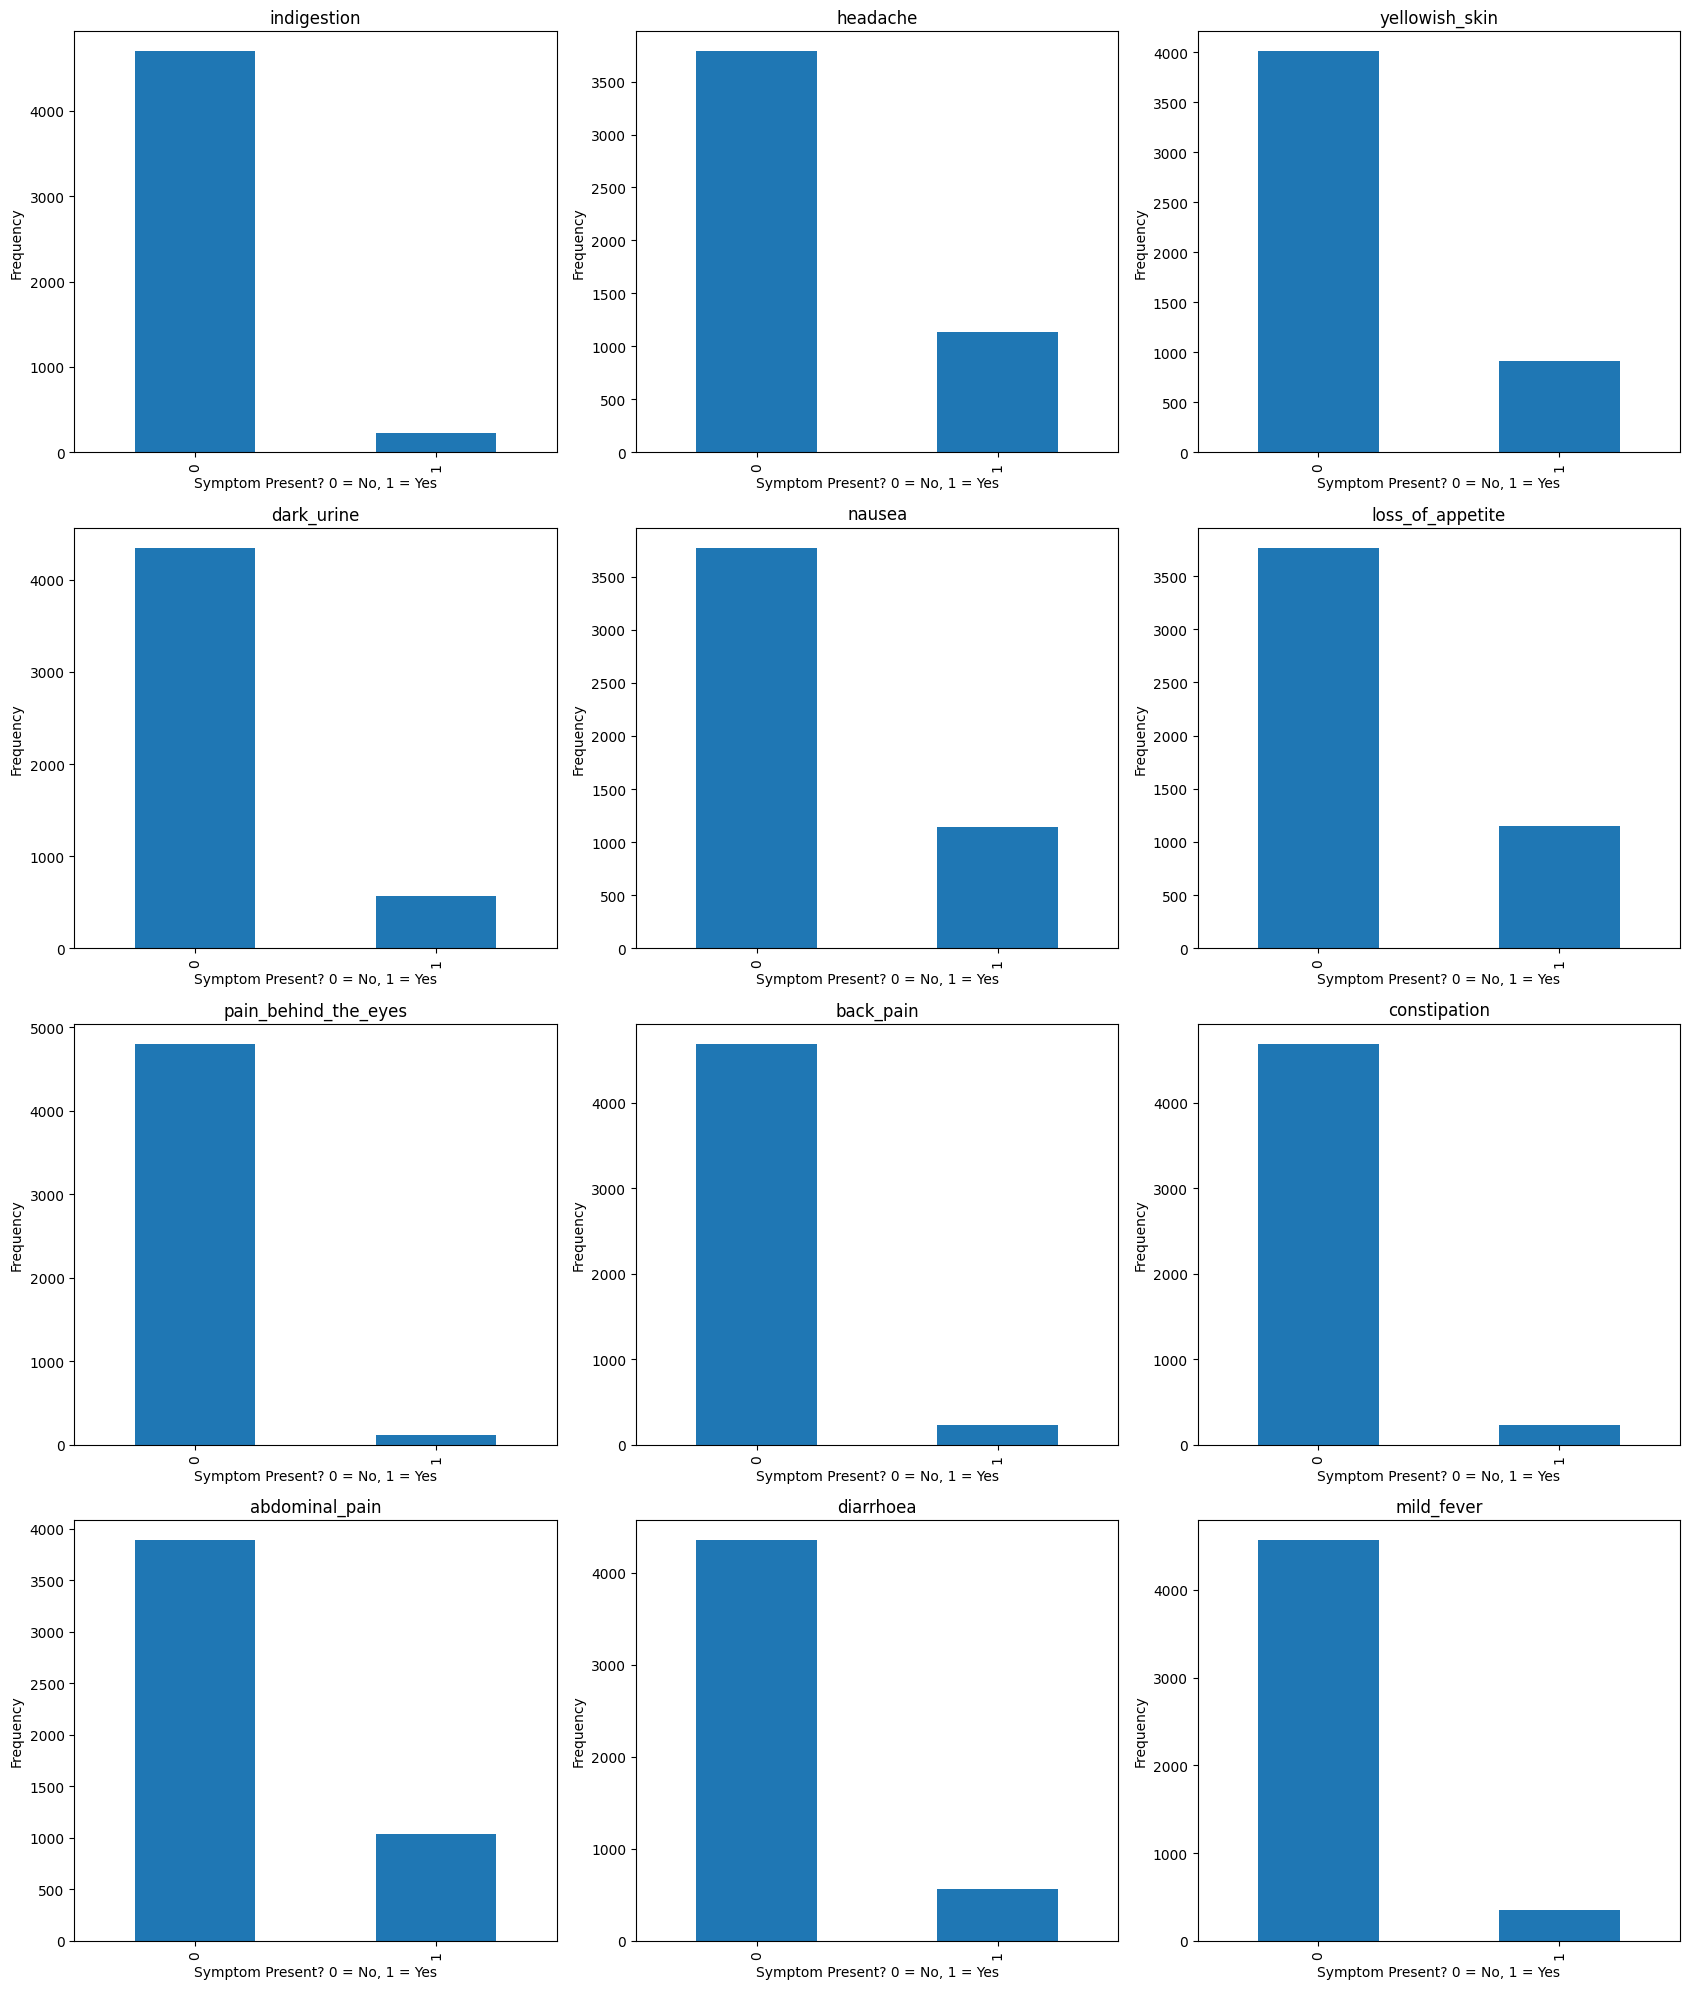

In [ ]:
sample_symptoms = [
    'indigestion', 'headache', 'yellowish_skin', 'dark_urine',
    'nausea', 'loss_of_appetite', 'pain_behind_the_eyes',
    'back_pain', 'constipation', 'abdominal_pain',
    'diarrhoea', 'mild_fever'
]

available_symptoms = [col for col in sample_symptoms if col in train_df.columns]

plt.figure(figsize=(17, 20))

for i, symptom in enumerate(available_symptoms):
    plt.subplot(4, 3, i + 1)
    train_df[symptom].value_counts().sort_index().plot(kind="bar")
    plt.title(symptom)
    plt.xlabel("Symptom Present? 0 = No, 1 = Yes")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Why are we doing this?

We want to understand how common different symptoms are.

A symptom that appears very often may be less specific.

A symptom that appears in only certain disease patterns may be more useful.

## Interpretation

The model learns from symptom patterns.

For example:

```text
yellowish_skin + dark_urine + abdominal_pain
```

may point toward certain disease groups.

The goal is not to diagnose manually, but to understand what kind of patterns the model may learn.


# 10. Correlation Heatmap

A heatmap helps us see which symptoms tend to appear together.


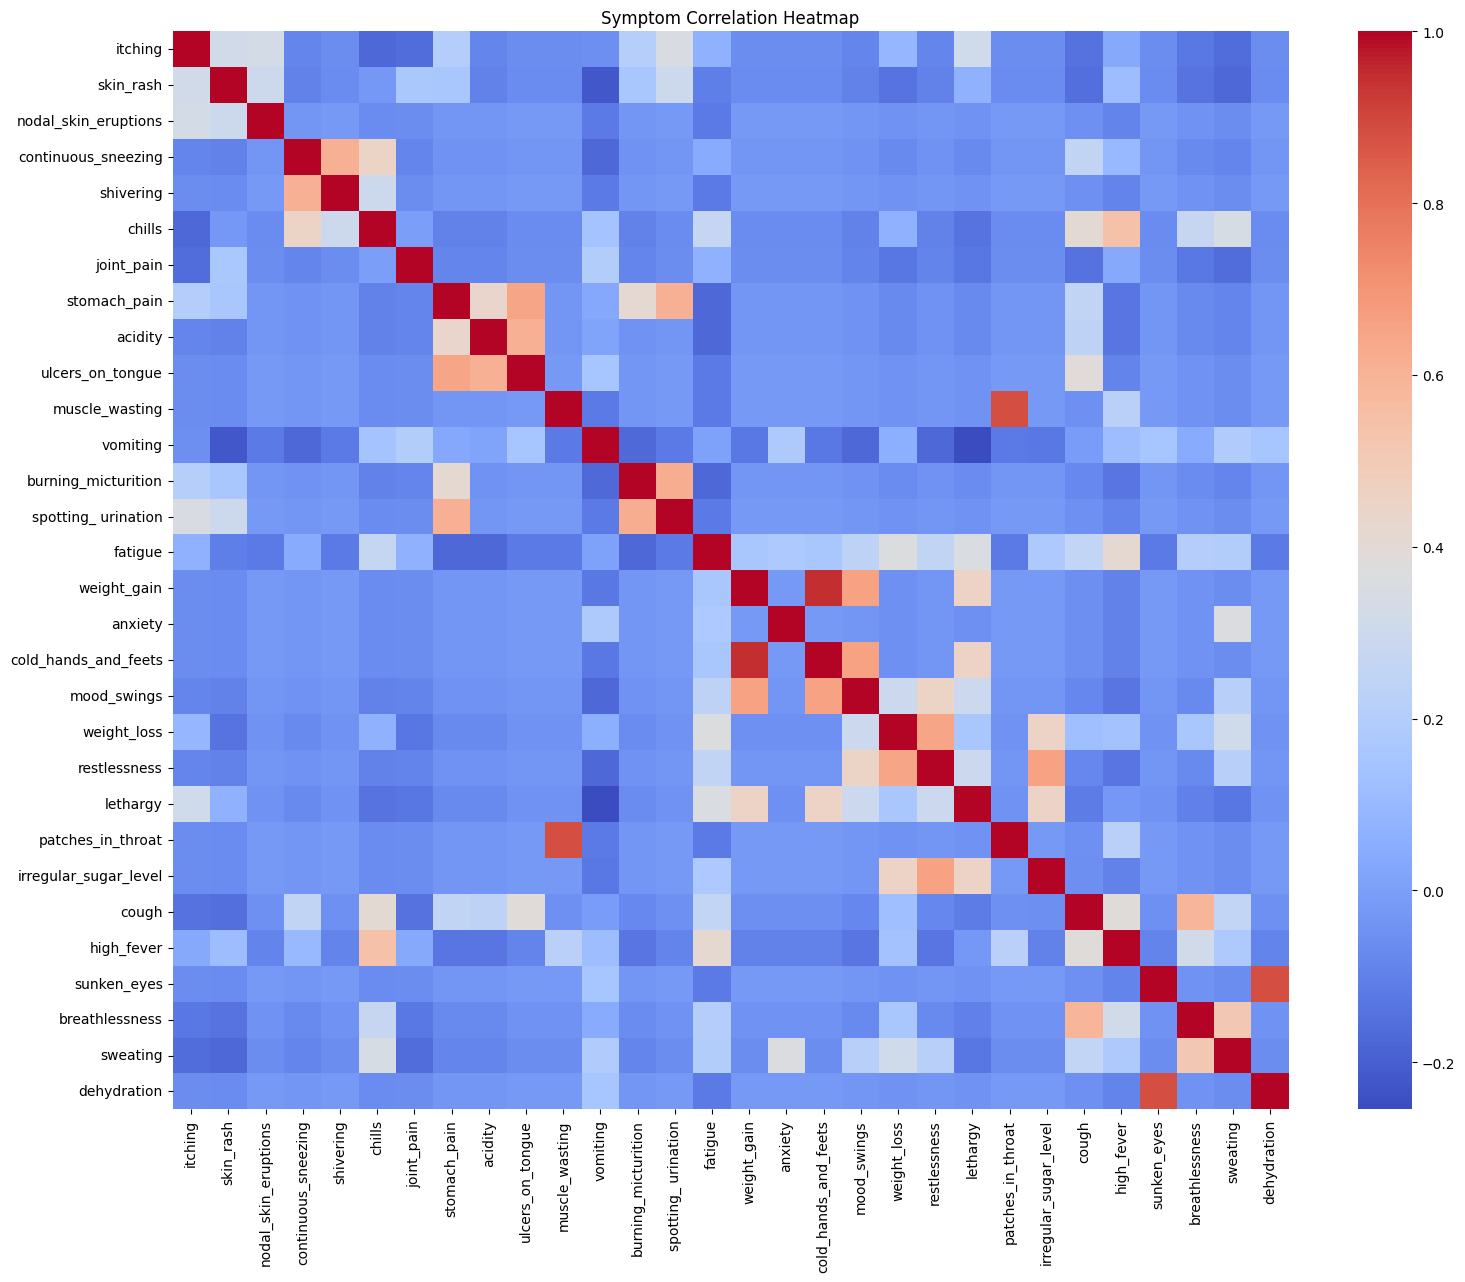

In [ ]:
symptom_columns = train_df.drop("prognosis", axis=1).columns

# Use a subset so the heatmap is readable.
heatmap_cols = symptom_columns[:30]

plt.figure(figsize=(18, 14))
sns.heatmap(train_df[heatmap_cols].corr(), cmap="coolwarm")
plt.title("Symptom Correlation Heatmap")
plt.show()

## Why are we doing this?

Symptoms are not always independent.

Some symptoms often appear together.

A heatmap helps us see relationships between symptom columns.

## Interpretation

If two symptoms are highly correlated, they often appear in the same patients.

This matters because the model may learn that certain groups of symptoms together suggest certain diseases.

In healthcare, symptoms rarely occur randomly — they often form patterns.


# 11. Clean Extra Columns

Some Kaggle CSV files contain an extra column such as `Unnamed: 133`.

This is usually not a real medical feature.


In [3]:
if "Unnamed: 133" in train_df.columns:
    train_df.drop("Unnamed: 133", axis=1, inplace=True)

if "Unnamed: 133" in test_df.columns:
    test_df.drop("Unnamed: 133", axis=1, inplace=True)

print(train_df.shape)
print(test_df.shape)

(4920, 133)
(42, 133)


## Why are we doing this?

A column like `Unnamed: 133` is usually created accidentally when saving a CSV.

It does not represent a symptom or a disease.

## Interpretation

We should train the model only on meaningful columns.

Removing irrelevant columns helps avoid errors and keeps the dataset clean.


# 12. Features and Labels

Now we split the data into:

- Features: the symptoms
- Label: the disease name


In [4]:
X_train = train_df.drop("prognosis", axis=1)
y_train = train_df["prognosis"]

X_test = test_df.drop("prognosis", axis=1)
y_test = test_df["prognosis"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4920, 132)
y_train shape: (4920,)
X_test shape: (42, 132)
y_test shape: (42,)


## Why are we doing this?

Machine learning models need inputs and correct answers.

```text
Features = symptoms
Label = disease
```

The model learns:

```text
Symptom pattern → Disease
```

## Interpretation

`X_train` contains symptom columns only.

`y_train` contains the correct disease labels.

This is supervised learning because we are training the model with examples and answers.


# 13. Before Training: How Logistic Regression Thinks

Before we train the model, let's build intuition.

## Think Like a Doctor

Suppose a patient has these symptoms:

| Symptom | Present? |
|---|---|
| Fever | Yes |
| Headache | Yes |
| Vomiting | No |
| Yellow Skin | No |
| Fatigue | Yes |

A doctor may think:

> These symptoms make flu more likely than hepatitis.

Machine learning works in a similar way.

The model looks at symptom patterns and learns which diseases are more likely.


## The Model Learns Patterns

During training, the model sees many examples.

| Fever | Headache | Yellow Skin | Disease |
|---|---|---|---|
| 1 | 1 | 0 | Flu |
| 1 | 0 | 1 | Hepatitis |
| 0 | 1 | 0 | Migraine |
| 1 | 1 | 1 | Dengue |

The model may learn patterns like:

```text
Fever + Headache
        ↓
More likely Flu

Yellow Skin
        ↓
More likely Hepatitis

Headache without Fever
        ↓
More likely Migraine
```

It is not memorizing one row.

It is learning relationships between symptoms and diseases.


## Why Is It Called Logistic Regression?

This name is confusing.

Although it contains the word **Regression**, Logistic Regression is used for **classification**.

### Linear Regression

Predicts numbers:

- House price
- Blood pressure
- Temperature

### Logistic Regression

Predicts classes:

- Disease / No Disease
- Flu / Dengue / Hepatitis
- Spam / Not Spam

Logistic Regression produces probabilities.

Example:

| Disease | Probability |
|---|---:|
| Flu | 82% |
| Dengue | 11% |
| Migraine | 5% |
| Hepatitis | 2% |

The disease with the highest probability becomes the prediction.


## Why Probabilities Matter

Imagine two predictions:

```text
Patient A:
Predicted Disease = Flu
Confidence = 99%
```

```text
Patient B:
Predicted Disease = Flu
Confidence = 52%
```

Both predictions say Flu.

But Patient A is much more confident.

In healthcare, this matters because doctors and users should know when an AI system is uncertain.


# 14. Train a Logistic Regression Classifier

Now we train the model.


In [5]:
model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## Why are we doing this?

We are asking the model to learn relationships between:

- symptom columns
- disease labels

## Interpretation

After training, the model has learned patterns from the training dataset.

It can now look at a new symptom pattern and predict the most likely disease.


# 15. Make Predictions

Now we use the test set to evaluate the model.


In [6]:
y_pred = model.predict(X_test)

y_pred[:10]

array(['Fungal infection', 'Allergy', 'GERD', 'Chronic cholestasis',
       'Drug Reaction', 'Peptic ulcer diseae', 'AIDS', 'Diabetes ',
       'Gastroenteritis', 'Bronchial Asthma'], dtype=object)

## Why are we doing this?

The test set contains examples the model did not learn from.

This helps us check how well the model works on unseen data.

## Interpretation

`y_pred` contains the model's predicted disease labels.

But predictions alone are not enough.

We need to compare them with the actual labels.


# 16. Basic Accuracy

Accuracy tells us the percentage of predictions the model got right.


In [7]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


## Why are we doing this?

Accuracy is an easy first metric.

It answers:

> Out of all predictions, how many were correct?

## Interpretation

High accuracy is good, but in healthcare we should not rely only on accuracy.

We also need precision, recall, F1-score, and error analysis.


# 17. Classification Report

A classification report gives precision, recall, and F1-score for each disease.


In [8]:
print(classification_report(y_test, y_pred))

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00      1.00         1
                           

## Why are we doing this?

The classification report helps us evaluate each disease separately.

It includes:

- **Precision**: When the model predicts this disease, how often is it correct?
- **Recall**: Out of all real cases of this disease, how many did the model find?
- **F1-score**: Balance between precision and recall.
- **Support**: How many real examples of that disease are in the test set.

## Interpretation

This is more useful than accuracy alone.

If one disease has low recall, the model may be missing that disease.

If one disease has low precision, the model may be falsely predicting that disease too often.


# 18. Confusion Matrix

A confusion matrix shows where the model is correct and where it makes mistakes.


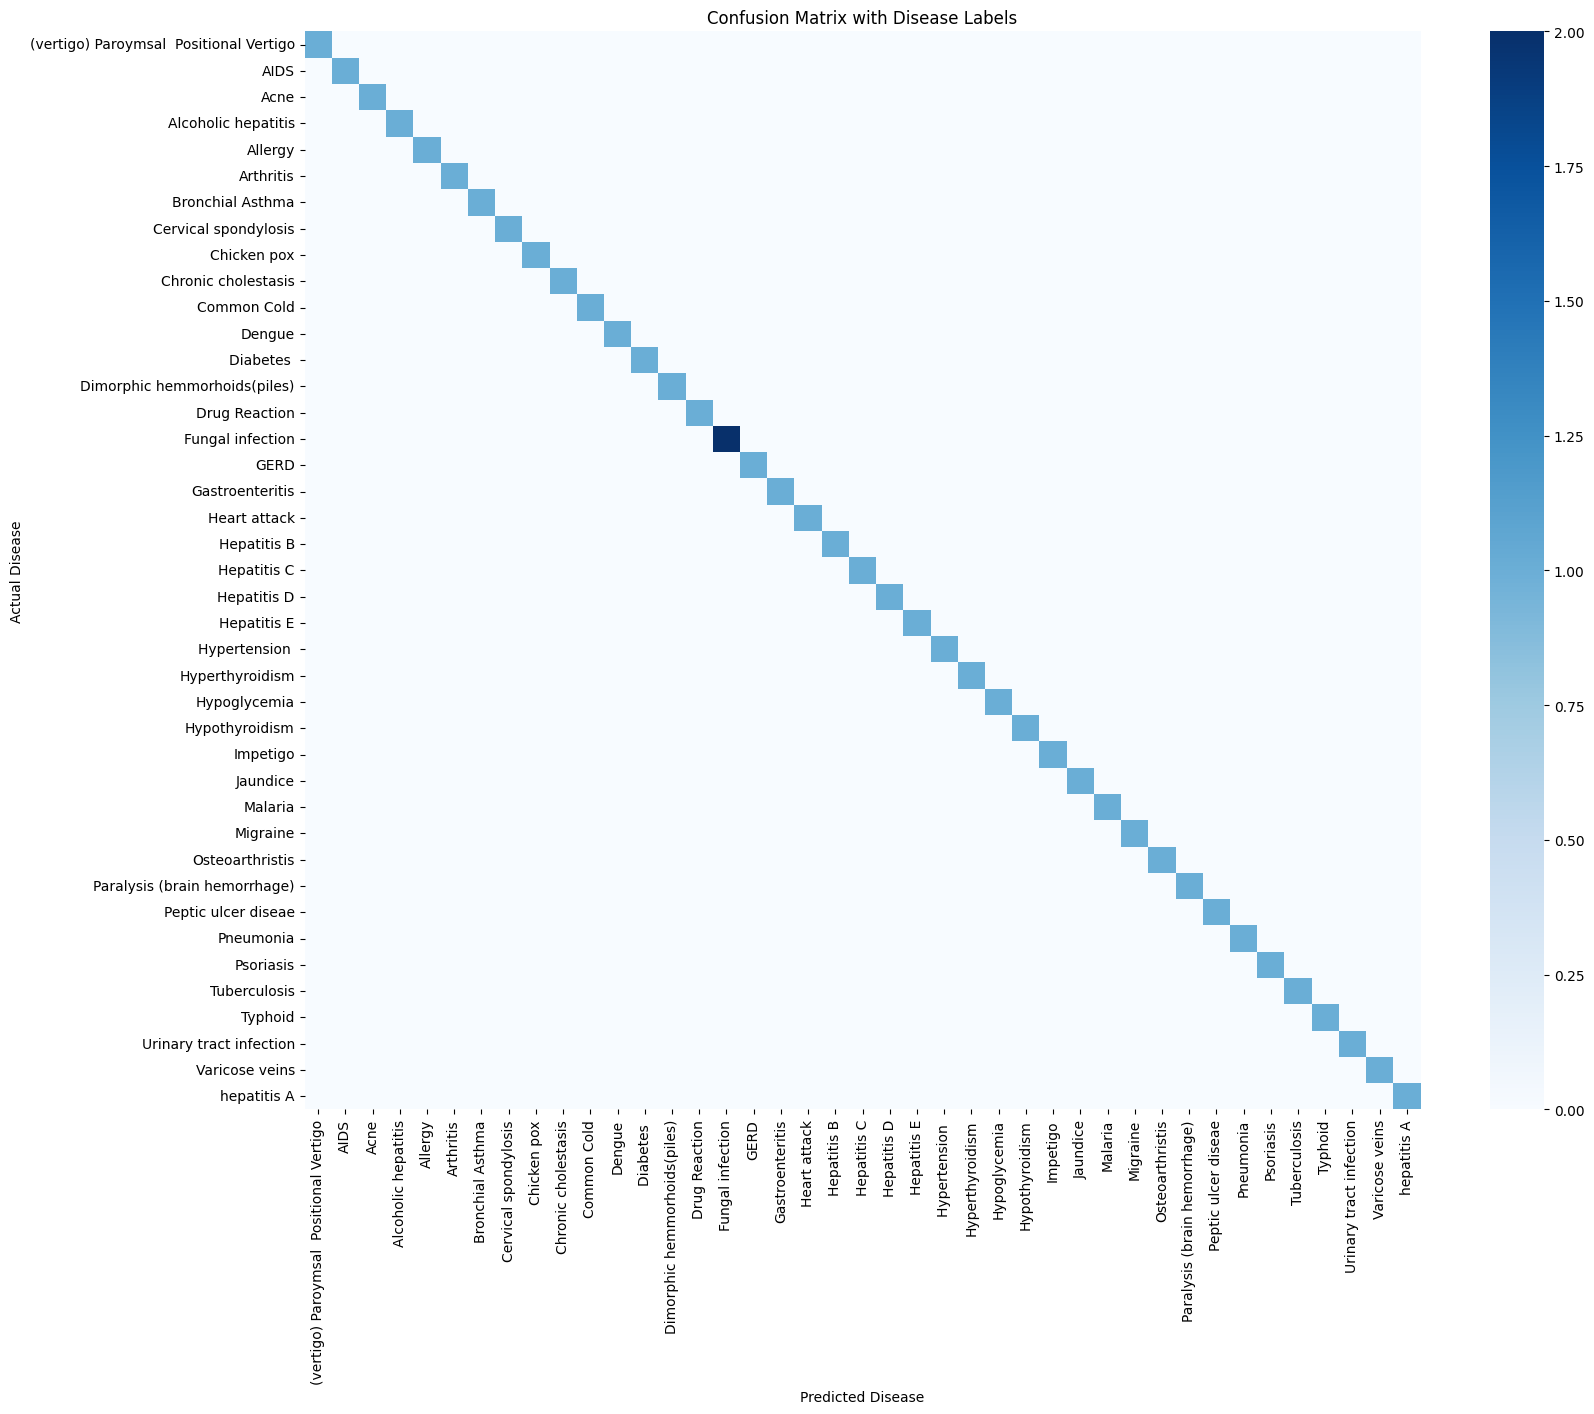

In [9]:
labels = sorted(y_test.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(18, 14))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix with Disease Labels")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

## Why are we doing this?

A confusion matrix lets us inspect mistakes.

The diagonal shows correct predictions.

Cells away from the diagonal show wrong predictions.

## Interpretation

If most values are on the diagonal, the model is performing well.

If many values are off the diagonal, the model is confusing some diseases.

In healthcare, understanding mistakes is just as important as getting a high score.


## Practice

Look at the confusion matrix and answer the questions below.


In [ ]:
# Practice:
# 1. Are most predictions on the diagonal?
# 2. Do you see any diseases that are confused with each other?
# 3. Why is this important in a healthcare app?


# 19. Model Confidence with Probabilities

`predict()` gives the final prediction.

`predict_proba()` gives probabilities for each possible disease.


In [11]:
X_test

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
probabilities = model.predict_proba(X_test)

probabilities[:3]

array([[8.99065057e-05, 1.95230111e-04, 7.33052475e-04, 8.41833023e-05,
        2.52944740e-04, 1.70178035e-04, 1.07398824e-04, 1.69955479e-04,
        2.89967746e-04, 3.86514913e-04, 3.85392807e-05, 5.77528989e-05,
        7.86077273e-05, 1.85897909e-04, 1.54700856e-03, 9.92542563e-01,
        9.99076026e-05, 2.09497455e-04, 1.94516196e-04, 1.03807289e-04,
        8.40103737e-05, 1.41171414e-05, 2.24651737e-05, 1.42483384e-04,
        6.62489464e-05, 4.77010221e-05, 6.51670620e-05, 4.52198216e-04,
        2.04459752e-04, 4.80576789e-05, 8.99425481e-05, 1.26768101e-04,
        1.84615589e-04, 9.86924120e-05, 5.53544897e-05, 3.55381773e-04,
        2.29422567e-05, 3.42536421e-05, 1.93366534e-04, 1.21843721e-04,
        3.25005774e-05],
       [1.04479485e-04, 3.15372179e-04, 3.19656541e-04, 1.35823605e-04,
        9.93669705e-01, 2.37749484e-04, 1.23306096e-04, 2.38368574e-04,
        4.75319696e-05, 7.75436087e-05, 1.73985610e-04, 8.44660180e-05,
        1.07058247e-04, 2.59569914e-04,

## Why are we doing this?

A model prediction is more useful when we know how confident the model is.

## Interpretation

Each row contains probabilities for all possible disease classes.

The disease with the highest probability becomes the prediction.

But the highest probability may be very high or only slightly higher than the others.


# 20. Top Disease Probabilities for One Patient

Let's inspect the top predictions for one patient.


In [12]:
patient_index = 0

patient_probs = pd.DataFrame({
    "disease": model.classes_,
    "probability": probabilities[patient_index]
})

patient_probs = patient_probs.sort_values(
    by="probability",
    ascending=False
)

patient_probs.head(5)

,disease,probability
15,Fungal infection,0.992543
14,Drug Reaction,0.001547
2,Acne,0.000733
27,Impetigo,0.000452
9,Chronic cholestasis,0.000387


## Why are we doing this?

Instead of showing only one predicted disease, we show the top possibilities.

## Interpretation

This is more realistic for healthcare.

A responsible system should be able to say:

```text
Most likely: Disease A
Second possibility: Disease B
Third possibility: Disease C
```

This helps users understand uncertainty.


# 21. Confidence Score for Every Prediction

The confidence score is the highest probability for each prediction.


In [13]:
confidence_scores = probabilities.max(axis=1)

results_df = X_test.copy()
results_df["actual_disease"] = y_test.values
results_df["predicted_disease"] = y_pred
results_df["confidence"] = confidence_scores

results_df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,actual_disease,predicted_disease,confidence
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,Fungal infection,Fungal infection,0.992543
1,0,0,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,Allergy,Allergy,0.993670
2,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,GERD,GERD,0.993216
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,Chronic cholestasis,Chronic cholestasis,0.983395
4,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,Drug Reaction,Drug Reaction,0.993565


## Why are we doing this?

We want to combine:

- patient symptoms
- actual disease
- predicted disease
- confidence

into one table.

## Interpretation

High confidence means the model strongly preferred one disease.

Low confidence means the model was less certain.

In a health app, low-confidence predictions should be treated carefully.


# 22. Error Analysis

Now we inspect mistakes.


In [14]:
mistakes = results_df[
    results_df["actual_disease"] != results_df["predicted_disease"]
]

mistakes.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,actual_disease,predicted_disease,confidence


In [15]:
print("Number of mistakes:", len(mistakes))
print("Total test examples:", len(results_df))

Number of mistakes: 0
Total test examples: 42


## Why are we doing this?

Real machine learning work is not just training a model.

We need to inspect where the model fails.

## Interpretation

Mistakes help us understand:

- Which diseases are confused
- Whether the model was confident or uncertain
- Whether symptoms overlap between diseases
- Whether the dataset may need better features

This is called **error analysis**.


# 23. Low-Confidence Edge Cases

Some predictions are technically correct but low confidence.

These are important edge cases.


In [16]:
low_confidence = results_df.sort_values("confidence").head(10)

low_confidence[
    ["actual_disease", "predicted_disease", "confidence"]
]

,actual_disease,predicted_disease,confidence
41,Fungal infection,Fungal infection,0.292088
22,Hepatitis D,Hepatitis D,0.980666
3,Chronic cholestasis,Chronic cholestasis,0.983395
19,hepatitis A,hepatitis A,0.987159
21,Hepatitis C,Hepatitis C,0.987690
29,Heart attack,Heart attack,0.989121
15,Malaria,Malaria,0.990085
23,Hepatitis E,Hepatitis E,0.990185
35,Arthritis,Arthritis,0.990930
14,Jaundice,Jaundice,0.991337


## Why are we doing this?

Low-confidence predictions show cases where the model was unsure.

These may be patients whose symptom patterns are similar to multiple diseases.

## Interpretation

A prediction with 99% confidence is very different from a prediction with 52% confidence.

In healthcare, the app should not treat both predictions equally.


# 24. Adding an 'Uncertain' Label

For a multi-class model, threshold tuning is different from binary classification.

Instead of changing a disease/no-disease threshold, we can create an uncertainty rule.

Example:

```text
If confidence < 0.60:
    prediction = "uncertain"
else:
    prediction = predicted disease
```


In [17]:
def prediction_with_uncertainty(predicted_label, confidence, threshold=0.60):
    if confidence < threshold:
        return "uncertain"
    return predicted_label

results_df["prediction_with_uncertainty"] = results_df.apply(
    lambda row: prediction_with_uncertainty(
        row["predicted_disease"],
        row["confidence"],
        threshold=0.60
    ),
    axis=1
)

results_df[
    ["actual_disease", "predicted_disease", "confidence", "prediction_with_uncertainty"]
].head(10)

,actual_disease,predicted_disease,confidence,prediction_with_uncertainty
0,Fungal infection,Fungal infection,0.992543,Fungal infection
1,Allergy,Allergy,0.993670,Allergy
2,GERD,GERD,0.993216,GERD
3,Chronic cholestasis,Chronic cholestasis,0.983395,Chronic cholestasis
4,Drug Reaction,Drug Reaction,0.993565,Drug Reaction
5,Peptic ulcer diseae,Peptic ulcer diseae,0.992490,Peptic ulcer diseae
6,AIDS,AIDS,0.993082,AIDS
7,Diabetes,Diabetes,0.994005,Diabetes
8,Gastroenteritis,Gastroenteritis,0.992400,Gastroenteritis
9,Bronchial Asthma,Bronchial Asthma,0.991823,Bronchial Asthma


## Why are we doing this?

In healthcare, it may be safer for a model to admit uncertainty than to make a confident-looking wrong prediction.

## Interpretation

This teaches a key responsible AI idea:

> A good AI system should know when it is unsure.

This is especially important in healthcare because wrong predictions can have serious consequences.


# 25. Threshold Discussion

In binary classification, we often tune a threshold like this:

```text
If disease probability >= 0.30:
    Predict Disease
else:
    Predict Control
```

Lower threshold:

```text
More disease predictions
Higher recall
More false alarms
```

Higher threshold:

```text
Fewer disease predictions
Higher precision
More missed cases
```

In this notebook, we are doing multi-class classification.

So instead of a disease/control threshold, we use confidence-based uncertainty.


# 26. Final Error Analysis Notes

Write short interpretation notes.

These notes are part of the final output for the session.


In [ ]:
# Final Notes:
#
# 1. Which diseases were predicted well?
#
# 2. Did the model make any mistakes?
#
# 3. Which predictions had low confidence?
#
# 4. Why should low-confidence predictions be handled carefully?
#
# 5. If this was a real health app, what warning should we show the user?


# 27. Mini Challenge

Try changing the uncertainty threshold.

For example:

- 0.50
- 0.60
- 0.70
- 0.80

Then answer:

1. How many predictions become uncertain?
2. Does a higher threshold make the system more cautious?
3. What threshold would you choose for a healthcare app?


In [ ]:
# Mini Challenge:
# Change the threshold value and count how many predictions become uncertain.

# Example:
# threshold = 0.70
# results_df["prediction_with_uncertainty"] = ...
# results_df["prediction_with_uncertainty"].value_counts()


# Session Wrap-Up

In this session, we learned:

1. What classification means
2. Binary vs multi-class classification
3. How symptoms can be used as ML features
4. How to train a Logistic Regression classifier
5. How to evaluate using accuracy, precision, recall, and F1-score
6. How to read a confusion matrix
7. How to inspect model confidence
8. How to perform error analysis
9. How to identify low-confidence edge cases
10. Why uncertainty matters in healthcare AI

The most important takeaway:

> Building a classifier is only the beginning. A responsible ML engineer must also understand mistakes, confidence, and edge cases.
